In [1]:
#imported neccessary Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Reading the Datasetj from csv file
ds = pd.read_csv('50_Startups.csv')

ds

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [5]:
ds = pd.get_dummies(ds, dtype= int, drop_first=True)

ds

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
ds.columns


Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [12]:
indep= ds[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']] #input
dep= ds[['Profit']] #output

In [13]:

# split into training set and test set
from sklearn.model_selection import train_test_split #
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)


In [80]:
from sklearn.tree import DecisionTreeRegressor # import DTR algorithm 
dtreg= DecisionTreeRegressor( criterion='poisson' ,splitter='random') #create object
regressor= dtreg.fit(X_train,y_train) # to create model

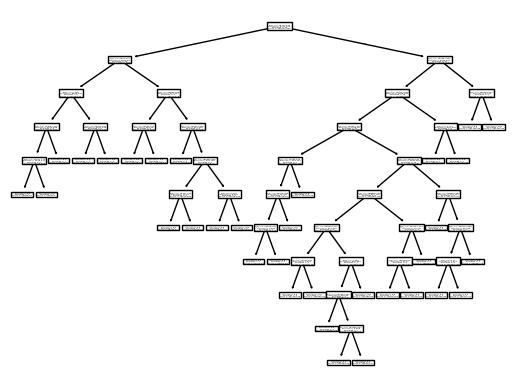

In [81]:
import matplotlib.pyplot as plt #import lib to draw tree
from sklearn import tree 
tree.plot_tree(regressor)
plt.show()

In [82]:

y_pred=regressor.predict(X_test)


In [83]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [84]:
r_score



0.9273117828863272

In [58]:
regressor.feature_importances_


array([0.79808448, 0.05643867, 0.13117611, 0.01277759, 0.00152315])

In [59]:
regressor.max_features_


5

In [60]:
regressor.tree_

In [62]:
rd_input= float(input("R&D:"))
admin_input= float(input("Admin"))
mark_input= float(input("Marketing "))
fol_input= int(input("State_flo 0 or 1:"))
new_input= int(input("State_new 0 or 1:"))

R&D: 3000
Admin 233
Marketing  443
State_flo 0 or 1: 0
State_new 0 or 1: 0


In [63]:
 result=regressor.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [64]:
result

array([49490.75])